In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('pd_cut_dataset.csv')

In [15]:
df

,id,value
0,1,-5.0
1,2,-2.5
2,3,-0.1
3,4,0.0
4,5,0.1
5,6,1.5
6,7,2.0
7,8,2.5
8,9,3.0
9,10,4.5


In [16]:
df['categorical_manual'] = pd.cut(df['value'], bins=[-np.inf, 0, 10, 20, 30])

In [17]:
df

,id,value,categorical_manual
0,1,-5.0,"(-inf, 0.0]"
1,2,-2.5,"(-inf, 0.0]"
2,3,-0.1,"(-inf, 0.0]"
3,4,0.0,"(-inf, 0.0]"
4,5,0.1,"(0.0, 10.0]"
5,6,1.5,"(0.0, 10.0]"
6,7,2.0,"(0.0, 10.0]"
7,8,2.5,"(0.0, 10.0]"
8,9,3.0,"(0.0, 10.0]"
9,10,4.5,"(0.0, 10.0]"


In [7]:
data = np.random.normal(loc=50, scale=10, size=1000000)
data

array([39.10071121, 44.70587751, 59.44568408, ..., 58.86864834,
       42.82985018, 68.48764459], shape=(1000000,))

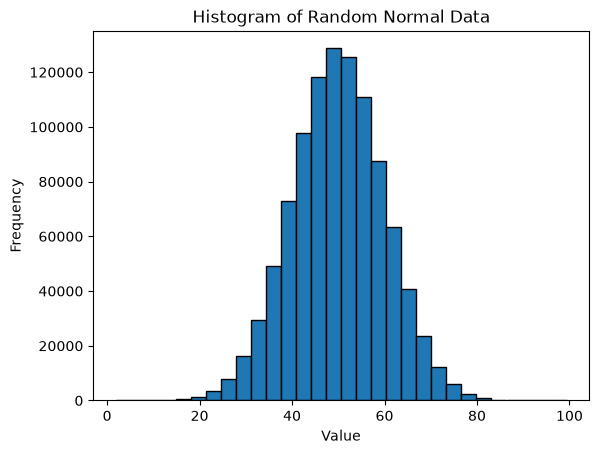

In [8]:
plt.hist(data, bins=30, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Random Normal Data')
plt.show()


In [18]:
data = {
    'Product': ['A', 'A', 'B', 'B', 'A', 'A'],
    'Region': ['North', 'North', 'North', 'North', 'South', 'South'],
    'Sales': [100, 150, 200, 180, 120, 140]
}



In [25]:
df = pd.DataFrame(data)
df

,Product,Region,Sales
0,A,North,100
1,A,North,150
2,B,North,200
3,B,North,180
4,A,South,120
5,A,South,140


In [26]:
df.groupby(['Product', 'Region'])['Sales'].sum().unstack()

Region,North,South
Product,,
A,250.0,260.0
B,380.0,NaN


In [27]:
pivot = df.pivot_table(index = 'Product', values = 'Sales', columns='Region', aggfunc='sum')
pivot

Region,North,South
Product,,
A,250.0,260.0
B,380.0,NaN


In [13]:
pivot.index

Index(['A', 'B'], dtype='str', name='Product')

In [12]:
pivot.melt(ignore_index=False).reset_index()

,Product,Region,value
0,A,East,180
1,B,East,160
2,A,North,100
3,B,North,150
4,A,South,200
5,B,South,120
